<a href="https://colab.research.google.com/github/mikysetiawan/MachineLearningExpert/blob/master/Tugas_Akhir_Timeseries_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import statsmodels.api as sm

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url, parse_dates=['Date'], index_col='Date')

df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53150 entries, 2017-09-21 09:00:00.000 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8+ MB


Checking null value

In [4]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Close,0
Volume USDT,0
RSI,0
MACD_Hist,0
ATR,0
KAMAO,0


Trying rolling mean to denoised data

TODO: DELETE = PERCOBAAN PAKAI DAILY DATA

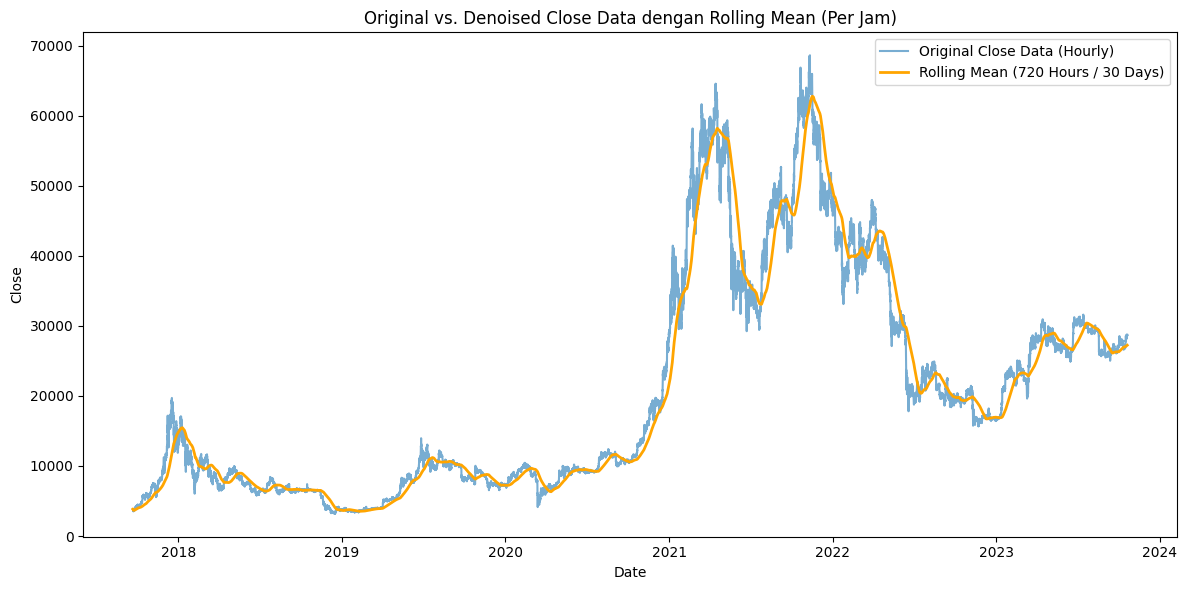

In [5]:
# Change index datatype to datetime
df.index = pd.to_datetime(df.index, format='mixed')

# Resample dataset into daily
# df_daily = df.resample('D').mean()
df_hourly = df.copy()

# Run rolling mean with window 1 month
# df_daily['Rolling_Mean'] = df_daily['Close'].rolling(window=30, min_periods=1).mean()

# Run rolling mean with window 1 month
# 30 hari * 24 jam = 720 jam.
df_hourly['Rolling_Mean'] = df_hourly['Close'].rolling(window=720, min_periods=1).mean()

# Show in figure
# plt.figure(figsize=(12, 6))
# plt.plot(df_daily.index, df_daily['Close'], label='Original Close Data (Daily)', alpha=0.6)
# plt.plot(df_daily.index, df_daily['Rolling_Mean'], label='Rolling Mean (30 Days)', color='orange', linewidth=2)
# plt.xlabel('Date')
# plt.ylabel('Close')
# plt.title('Original vs. Denoised Close Data dengan Rolling Mean')
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_hourly.index, df_hourly['Close'], label='Original Close Data (Hourly)', alpha=0.6)
plt.plot(df_hourly.index, df_hourly['Rolling_Mean'], label='Rolling Mean (720 Hours / 30 Days)', color='orange', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Denoised Close Data dengan Rolling Mean (Per Jam)')
plt.legend()
plt.tight_layout()
plt.show()

# ========== EDA =============

Seasonal and Trend decomposition using Loess

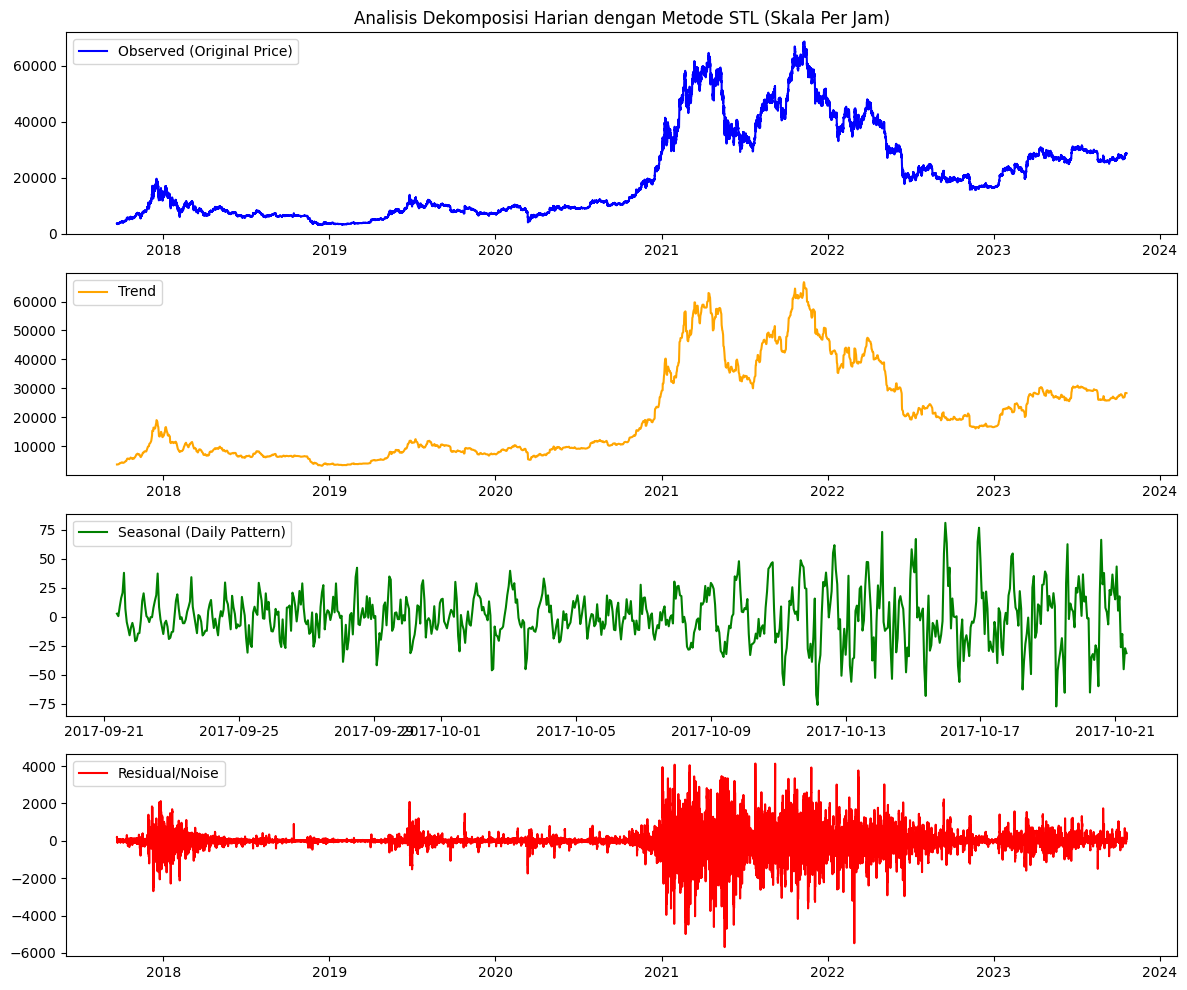

In [6]:
# Hitung dekomposisi dari data 'Close' asli
stl = STL(df_hourly['Close'], period=24, robust=True)
decomposition = stl.fit()

plt.figure(figsize=(12, 10))

# 1. Observed
plt.subplot(411)
plt.plot(df_hourly.index, decomposition.observed, label='Observed (Original Price)', color='blue')
plt.legend(loc='upper left')
plt.title('Analisis Dekomposisi Harian dengan Metode STL (Skala Per Jam)')

# 2. Trend
plt.subplot(412)
plt.plot(df_hourly.index, decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

# 3. Seasonal (Menampilkan grafik 1 bulan pertama = 720 jam untuk melihat polanya)
plt.subplot(413)
plt.plot(df_hourly.index[:720], decomposition.seasonal[:720], label='Seasonal (Daily Pattern)', color='green')
plt.legend(loc='upper left')

# 4. Residual
plt.subplot(414)
plt.plot(df_hourly.index, decomposition.resid, label='Residual/Noise', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Check stationary data with ADF

In [7]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df_hourly['Close'])

ADF Test Results:
ADF Statistic: -1.5594011394616105
p-value: 0.5039489237257468
Data tidak stasioner


In [8]:
print("===== adf test Volume USDT ==========")
adf_test(df_hourly['Volume USDT'])
print("===== adf test RSI ==========")
adf_test(df_hourly['RSI'])
print("===== adf test MACD_Hist ==========")
adf_test(df_hourly['MACD_Hist'])
print("===== adf test ATR ==========")
adf_test(df_hourly['ATR'])
print("===== adf test KAMAO ==========")
adf_test(df_hourly['KAMAO'])

===== adf test Volume USDT ==========
ADF Test Results:
ADF Statistic: -8.370741375695141
p-value: 2.6665450890014613e-13
Data stasioner
===== adf test RSI ==========
ADF Test Results:
ADF Statistic: -8.23940675812908
p-value: 5.771375320348243e-13
Data stasioner
===== adf test MACD_Hist ==========
ADF Test Results:
ADF Statistic: -13.057517328088691
p-value: 2.0799966877462827e-24
Data stasioner
===== adf test ATR ==========
ADF Test Results:
ADF Statistic: -1.8613754244450191
p-value: 0.3504436609247079
Data tidak stasioner
===== adf test KAMAO ==========
ADF Test Results:
ADF Statistic: -14.416472567986332
p-value: 8.043618591043793e-27
Data stasioner


In [9]:
df_features = pd.DataFrame(index=df_hourly.index)
df_features['Trend_STL'] = decomposition.trend
df_features['Seasonal_STL'] = decomposition.seasonal
df_features['Hour'] = df_features.index.hour
df_features['Close'] = df_hourly['Close']
df_features['Volume USDT'] = df_hourly['Volume USDT']
df_features['ATR'] = df_hourly['ATR']
df_features['RSI'] = df_hourly['RSI']
df_features['MACD_Hist'] = df_hourly['MACD_Hist']
df_features['KAMAO'] = df_hourly['KAMAO']

# ---- PEMBUKTIAN ----
# Mari kita uji ulang apakah DataFrame baru ini sudah 100% stasioner semuanya
print("=== VERIFIKASI AKHIR DATASET STASIONER ===")
for col in df_features.columns:
    print(f"\n===== adf test {col} =====")
    adf_test(df_features[col])

=== VERIFIKASI AKHIR DATASET STASIONER ===

===== adf test Trend_STL =====
ADF Test Results:
ADF Statistic: -1.486075255628424
p-value: 0.5403881211227265
Data tidak stasioner

===== adf test Seasonal_STL =====
ADF Test Results:
ADF Statistic: -56.4105760975827
p-value: 0.0
Data stasioner

===== adf test Hour =====
ADF Test Results:
ADF Statistic: -37.091484822796836
p-value: 0.0
Data stasioner

===== adf test Close =====
ADF Test Results:
ADF Statistic: -1.5594011394616105
p-value: 0.5039489237257468
Data tidak stasioner

===== adf test Volume USDT =====
ADF Test Results:
ADF Statistic: -8.370741375695141
p-value: 2.6665450890014613e-13
Data stasioner

===== adf test ATR =====
ADF Test Results:
ADF Statistic: -1.8613754244450191
p-value: 0.3504436609247079
Data tidak stasioner

===== adf test RSI =====
ADF Test Results:
ADF Statistic: -8.23940675812908
p-value: 5.771375320348243e-13
Data stasioner

===== adf test MACD_Hist =====
ADF Test Results:
ADF Statistic: -13.057517328088691
p-v

TODO: DELETE = PERCOBAAN PAKAI DAILY DATA

In [10]:
# # Buat DataFrame baru khusus untuk fitur model forecasting
# df_features = pd.DataFrame(index=df_daily.index)

# # 1. Transformasi target harga (gunakan Close atau Rolling Mean Anda)
# # Diubah menjadi persentase return harian agar stasioner sempurna
# df_features['Close'] = df_daily['Close'].diff()

# # 2. Transformasi Volume USDT (Gunakan diff karena tidak stasioner)
# df_features['Volume USDT'] = df_daily['Volume USDT'].diff()

# # 3. Transformasi ATR (Gunakan Log + Diff karena varians tidak konstan)
# df_features['ATR'] = np.log(df_daily['ATR']).diff()

# # 4. Kolom yang sudah lolos (Stasioner) langsung dimasukkan tanpa diubah
# df_features['RSI'] = df_daily['RSI']
# df_features['MACD_Hist'] = df_daily['MACD_Hist']
# df_features['KAMAO'] = df_daily['KAMAO']

# # Wajib gunakan .dropna() karena efek .diff() dan .pct_change() menyisakan nilai kosong di baris paling awal
# df_features.dropna(inplace=True)

# # ---- PEMBUKTIAN ----
# # Mari kita uji ulang apakah DataFrame baru ini sudah 100% stasioner semuanya
# print("=== VERIFIKASI AKHIR DATASET STASIONER ===")
# for col in df_features.columns:
#     print(f"\n===== adf test {col} =====")
#     adf_test(df_features[col])


ACF & PACF

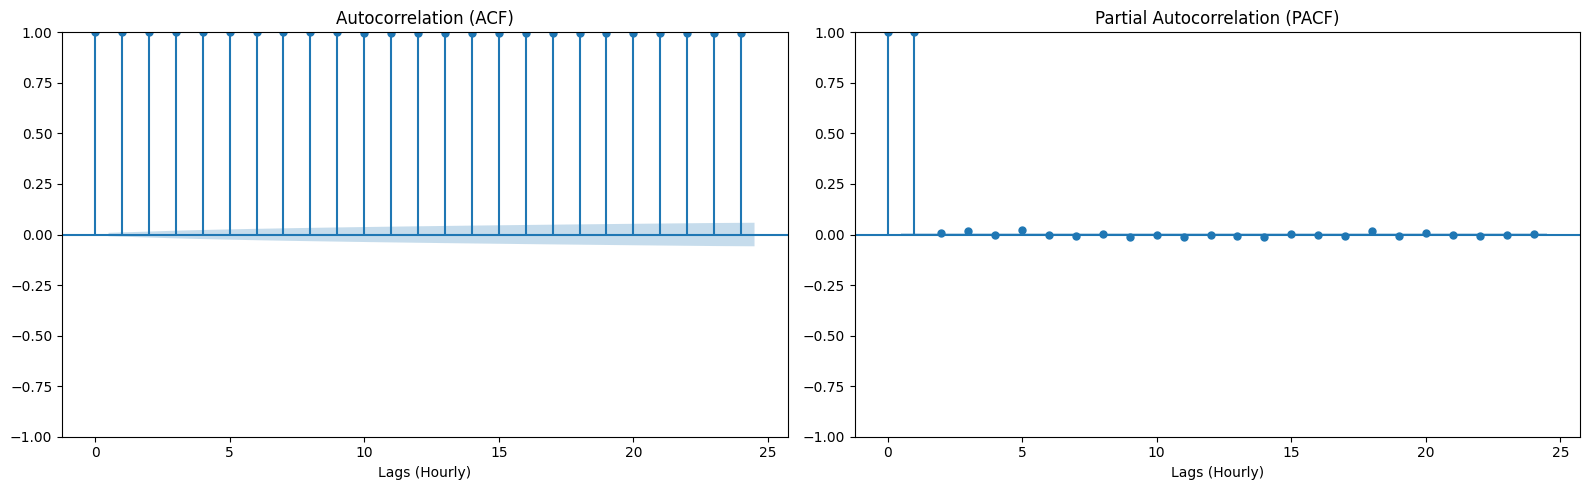

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(df_features['Close'], lags=24, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lags (Hourly)')

# Plot Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(df_features['Close'], lags=24, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lags (Hourly)')

plt.tight_layout()
plt.show()

Membuat fitur rolling standard deviation per 30 hari

In [12]:
# Membuat fitur baru: Volatilitas harga berbasis Rolling Standard Deviation 24 Jam
df_features['Close_Volatilitas_24h'] = df_features['Close'].rolling(window=24).std()

# Karena rolling menyebabkan data pertama menjadi NaN, kita isi dengan metode bfill
df_features['Close_Volatilitas_24h'] = df_features['Close_Volatilitas_24h'].bfill()

# Bersihkan data jika ada nilai kosong (NaN) akibat proses kalkulasi
df_features.dropna(inplace=True)

print("Daftar fitur baru yang siap digunakan:")
print(df_features.head())

Daftar fitur baru yang siap digunakan:
                       Trend_STL  Seasonal_STL  Hour    Close    Volume USDT  \
Date                                                                           
2017-09-21 09:00:00  3657.721516      2.539107     9  3860.00   74434.891166   
2017-09-21 10:00:00  3657.101069      0.413535    10  3871.48   44687.318944   
2017-09-21 11:00:00  3656.466229      8.654769    11  3864.95   80546.171672   
2017-09-21 12:00:00  3655.816934     15.981174    12  3858.08   90331.531390   
2017-09-21 13:00:00  3655.152469     20.543084    13  3856.67  103405.818040   

                           ATR        RSI  MACD_Hist     KAMAO  \
Date                                                             
2017-09-21 09:00:00  88.054720  49.192454 -48.279697  2.495591   
2017-09-21 10:00:00  87.996283  49.233202 -47.780476  2.616710   
2017-09-21 11:00:00  87.897128  49.210685 -47.308061  2.532239   
2017-09-21 12:00:00  87.720856  49.186948 -46.863233  2.447245   
2017

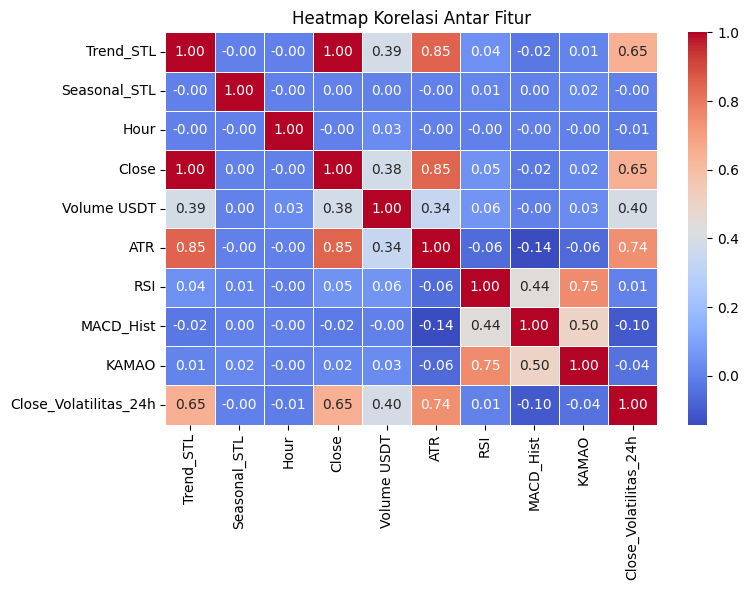

In [13]:
plt.figure(figsize=(8, 6))
# Menghitung korelasi antar fitur
correlation_matrix = df_features.corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

# ========== Creating LSTM Model =============

In [14]:
# 1. Inisialisasi MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Lakukan Fit dan Transform pada seluruh kolom di df_features
# Ini akan menghasilkan array NumPy 2D yang berisi nilai antara 0 hingga 1
scaled_features = scaler.fit_transform(df_features)

# (Opsional) Verifikasi hasil untuk memastikan dimensinya sudah sesuai
print("Ukuran scaled_features:", scaled_features.shape)
print("Contoh data baris pertama:", scaled_features[0])

Ukuran scaled_features: (53150, 10)
Contoh data baris pertama: [6.95102095e-03 5.23028424e-01 3.91304348e-01 1.05092081e-02
 2.47651242e-05 7.15416896e-02 4.75388057e-01 5.54088518e-01
 4.79149283e-01 2.48317789e-02]


In [15]:
def create_dataset_numpy(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), :])
        Y.append(dataset[i + time_step, 0])  # Target: Close price di indeks 0
    return np.array(X), np.array(Y)

# Berdasarkan grafik PACF data return (pct_change),
# cut-off terjadi di Lag 1, menunjukkan hubungan autoregresif murni jangka pendek.
# Oleh karena itu, dipilih TIME_STEP = 24 untuk memberi ruang bagi LSTM mempelajari sekuens mingguan
# agar model tidak overfitting pada noise harian
TIME_STEP = 24

# 2. Buat matriks fitur X dan y dalam bentuk NumPy terlebih dahulu
# (Asumsi: `scaled_features` adalah array hasil MinMaxScaler dari df_features Anda)
X_all, y_all = create_dataset_numpy(scaled_features, TIME_STEP)

# 3. Bagi data menjadi Train (80%), Validation (10%), dan Test (10%)
total_samples = len(X_all)
train_end = int(total_samples * 0.80)
val_end = int(total_samples * 0.90)

X_train_np, y_train_np = X_all[:train_end], y_all[:train_end]
X_val_np, y_val_np = X_all[train_end:val_end], y_all[train_end:val_end]
X_test_np, y_test_np = X_all[val_end:], y_all[val_end:]

# 4. Konversi NumPy Array menjadi tf.data.Dataset Pipeline
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_np, y_train_np))
# Shuffle hanya untuk data training agar model lebih robust
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_np, y_val_np))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test_np, y_test_np))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Verifikasi dimensi akhir pipeline
print("Data berhasil dibagi dan dikonversi ke tf.data.Dataset:")
print(f"Train Dataset: {X_train_np.shape[0]} sampel")
print(f"Validation Dataset: {X_val_np.shape[0]} sampel")
print(f"Test Dataset: {X_test_np.shape[0]} sampel")

Data berhasil dibagi dan dikonversi ke tf.data.Dataset:
Train Dataset: 42500 sampel
Validation Dataset: 5312 sampel
Test Dataset: 5313 sampel


In [16]:
# 1. Inisialisasi Model LSTM Dasar
model = Sequential([
    # Menggunakan Input layer eksplisit sesuai saran warning TensorFlow terbaru
    tf.keras.layers.Input(shape=(X_train_np.shape[1], X_train_np.shape[2])),
    LSTM(units=50, activation='tanh'),
    Dense(units=1)
])

# 2. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 3. Training Model Menggunakan tf.data.Dataset Pipeline
history = model.fit(
    train_dataset,
    validation_data=val_dataset, # Menggunakan data validation terpisah
    epochs=10,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,251 (47.86 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.5156e-04 - val_loss: 2.6549e-05
Epoch 2/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.8578e-05 - val_loss: 5.6377e-06
Epoch 3/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.0740e-05 - val_loss: 4.4242e-06
Epoch 4/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.9611e-05 - val_loss: 3.8373e-06
Epoch 5/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.6789e-05 - val_loss: 5.1887e-06
Epoch 6/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.6881e-05 - val_loss: 9.9515e-05
Epoch 7/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.1926e-05 - val_loss: 1.4933e-05
Epoch 8/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.2843e-05 - val_loss: 2.0482e-05
Epoch 9/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.1533e-05 - val_loss: 2.2710e-06
Epoch 10/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.3019e-06 - val_loss: 1.9900e-06


# ========== Custom Architechture Model ==========

In [17]:
def create_multistep_dataset(dataset, time_step=7, forecast_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step - forecast_step + 1):
        X.append(dataset[i:(i + time_step), :])
        # Mengambil kolom 'Close' (indeks 0) untuk 24 langkah ke depan
        Y.append(dataset[(i + time_step):(i + time_step + forecast_step), 0])
    return np.array(X), np.array(Y)

FORECAST_STEP = 24
X_all_ms, y_all_ms = create_multistep_dataset(scaled_features, time_step=TIME_STEP, forecast_step=FORECAST_STEP)

# Split data (80% Train, 10% Val, 10% Test)
total_samples = len(X_all_ms)
train_end = int(total_samples * 0.80)
val_end = int(total_samples * 0.90)

X_train_ms, y_train_ms = X_all_ms[:train_end], y_all_ms[:train_end]
X_val_ms, y_val_ms = X_all_ms[train_end:val_end], y_all_ms[train_end:val_end]

# Pipeline tf.data.Dataset
BATCH_SIZE = 64
train_ds_ms = tf.data.Dataset.from_tensor_slices((X_train_ms, y_train_ms)).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds_ms = tf.data.Dataset.from_tensor_slices((X_val_ms, y_val_ms)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Multi-step Train Shape: {X_train_ms.shape}, Target Shape: {y_train_ms.shape}")

Multi-step Train Shape: (42482, 24, 10), Target Shape: (42482, 24)


In [18]:
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer="glorot_uniform", trainable=True, name="w")
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim

    def build(self, input_shape):
        self.wq = CustomDense(self.num_heads * self.key_dim)
        self.wk = CustomDense(self.num_heads * self.key_dim)
        self.wv = CustomDense(self.num_heads * self.key_dim)
        self.wo = CustomDense(input_shape[-1])

    def call(self, q, v, k=None):
        if k is None: k = v
        # Linear projections
        query = self.wq(q)
        key = self.wk(k)
        value = self.wv(v)
        # Sederhana: Dot-product attention untuk sekuens waktu
        scores = tf.matmul(query, key, transpose_b=True)
        scores = scores / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, value)
        return self.wo(output)

class CustomLeakyRelu(tf.keras.layers.Layer):
    def __init__(self, alpha=0.2, **kwargs):
        super(CustomLeakyRelu, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, inputs):
        return tf.where(inputs > 0, inputs, inputs * self.alpha)

In [19]:
# --- 1. Baseline dengan Built-in Attention & Custom Dense & Custom LeakyReLU ---
inputs = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]))
lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)

# Built-in MultiHeadAttention
mha_builtin = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32)(lstm_out, lstm_out)
lstm_flat = tf.keras.layers.Flatten()(mha_builtin)

dense_out = CustomDense(64)(lstm_flat)
act_out = CustomLeakyRelu()(dense_out)
outputs = CustomDense(FORECAST_STEP)(act_out)

model_baseline_builtin = tf.keras.Model(inputs, outputs, name="Baseline_LSTM_BuiltIn_MHA")
model_baseline_builtin.compile(optimizer='adam', loss='mse')
print("\n--- Training Baseline dengan Built-in MHA ---")
model_baseline_builtin.fit(train_ds_ms, validation_data=val_ds_ms, epochs=5, verbose=1)


# --- 2. Baseline dengan Custom Multi-Head Attention ---
inputs_c = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]))
lstm_out_c = tf.keras.layers.LSTM(64, return_sequences=True)(inputs_c)

# Menggunakan Custom MultiHeadAttention yang dibuat dari nol
mha_custom = CustomMultiHeadAttention(num_heads=2, key_dim=32)(lstm_out_c, lstm_out_c)
lstm_flat_c = tf.keras.layers.Flatten()(mha_custom)

dense_out_c = CustomDense(64)(lstm_flat_c)
act_out_c = CustomLeakyRelu()(dense_out_c)
outputs_c = CustomDense(FORECAST_STEP)(act_out_c)

model_baseline_custom = tf.keras.Model(inputs_c, outputs_c, name="Baseline_LSTM_Custom_MHA")
model_baseline_custom.compile(optimizer='adam', loss='mse')
print("\n--- Training Baseline dengan Custom MHA ---")
model_baseline_custom.fit(train_ds_ms, validation_data=val_ds_ms, epochs=5, verbose=1)


--- Training Baseline dengan Built-in MHA ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 3.3301e-04 - val_loss: 1.3332e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.8933e-04 - val_loss: 1.3989e-04
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.5384e-04 - val_loss: 1.9308e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.6719e-04 - val_loss: 5.3907e-05
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.4824e-04 - val_loss: 6.0110e-05

--- Training Baseline dengan Custom MHA ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 4.7897e-04 - val_loss: 7.7361e-05
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.7753e-04 - val_loss: 1.5114e-04
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 1.6320e-04 - val_loss: 1.8893e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.7185e-04 - val_loss: 8.0549e-05
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.5212e-

SEQ2SEQ

In [20]:
# Menyiapkan decoder_input untuk Teacher Forcing (geser target y_train ke kanan)
dec_train_inputs = np.zeros_like(y_train_ms)
dec_train_inputs[:, 1:] = y_train_ms[:, :-1] # Teacher forcing input
dec_train_inputs = np.expand_dims(dec_train_inputs, axis=-1)

dec_val_inputs = np.zeros_like(y_val_ms)
dec_val_inputs[:, 1:] = y_val_ms[:, :-1]
dec_val_inputs = np.expand_dims(dec_val_inputs, axis=-1)

# Dataset khusus Seq2Seq Functional
train_s2s_ds = tf.data.Dataset.from_tensor_slices(((X_train_ms, dec_train_inputs), y_train_ms)).shuffle(1024).batch(BATCH_SIZE)
val_s2s_ds = tf.data.Dataset.from_tensor_slices(((X_val_ms, dec_val_inputs), y_val_ms)).batch(BATCH_SIZE)

# --- Membangun Arsitektur Seq2Seq dengan Functional API ---
encoder_inputs = tf.keras.layers.Input(shape=(X_train_ms.shape[1], X_train_ms.shape[2]), name="enc_input")
encoder_lstm = tf.keras.layers.LSTM(64, return_state=True, return_sequences=True)
enc_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = tf.keras.layers.Input(shape=(FORECAST_STEP, 1), name="dec_input")
decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True)
dec_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)

# Menambahkan Custom MHA di dalam Seq2Seq
s2s_attention = CustomMultiHeadAttention(num_heads=2, key_dim=32)(dec_outputs, enc_outputs)

# Output Dense Layer menggunakan Custom Dense dan Custom LeakyRelu
s2s_dense = CustomDense(64)(s2s_attention)
s2s_act = CustomLeakyRelu()(s2s_dense)
s2s_final = CustomDense(1)(s2s_act)
s2s_outputs = tf.keras.layers.Reshape((FORECAST_STEP,))(s2s_final)

model_s2s_functional = tf.keras.Model([encoder_inputs, decoder_inputs], s2s_outputs, name="Seq2Seq_Functional_TeacherForcing")
model_s2s_functional.compile(optimizer='adam', loss='mse')

print("\n--- Training Seq2Seq Functional API dengan Teacher Forcing ---")
model_s2s_functional.fit(train_s2s_ds, validation_data=val_s2s_ds, epochs=5, verbose=1)


--- Training Seq2Seq Functional API dengan Teacher Forcing ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 4.5743e-04 - val_loss: 1.0505e-04
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.7069e-04 - val_loss: 6.7537e-05
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.6701e-04 - val_loss: 1.0452e-04
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.6906e-04 - val_loss: 1.0205e-04
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.4462e-04 - val_loss: 8.9698e-05


In [21]:
class Seq2SeqSubclass(tf.keras.Model):
    def __init__(self, forecast_step, **kwargs):
        super(Seq2SeqSubclass, self).__init__(**kwargs)
        self.forecast_step = forecast_step
        self.encoder_lstm = tf.keras.layers.LSTM(64, return_state=True, return_sequences=True)
        self.decoder_lstm = tf.keras.layers.LSTM(64, return_sequences=True)
        self.attention = CustomMultiHeadAttention(num_heads=2, key_dim=32)
        self.dense1 = CustomDense(64)
        self.leaky_relu = CustomLeakyRelu()
        self.dense2 = CustomDense(1)
        self.reshape = tf.keras.layers.Reshape((forecast_step,))

    def call(self, inputs):
        # inputs berupa tuple dari (encoder_inputs, decoder_inputs)
        enc_inputs, dec_inputs = inputs

        # Encoder
        enc_outputs, state_h, state_c = self.encoder_lstm(enc_inputs)
        encoder_states = [state_h, state_c]

        # Decoder
        dec_outputs = self.decoder_lstm(dec_inputs, initial_state=encoder_states)

        # Attention & Custom Custom Layers
        context = self.attention(dec_outputs, enc_outputs)
        x = self.dense1(context)
        x = self.leaky_relu(x)
        x = self.dense2(x)
        return self.reshape(x)

# Inisialisasi, Compile, dan Training Model Subclassing
model_s2s_subclass = Seq2SeqSubclass(forecast_step=FORECAST_STEP, name="Seq2Seq_Subclass_TeacherForcing")
model_s2s_subclass.compile(optimizer='adam', loss='mse')

# Format input untuk model subclassing sama dengan format data s2s functional di atas
print("\n--- Training Seq2Seq Model Subclassing dengan Teacher Forcing ---")
model_s2s_subclass.fit(train_s2s_ds, validation_data=val_s2s_ds, epochs=5, verbose=1)


--- Training Seq2Seq Model Subclassing dengan Teacher Forcing ---
Epoch 1/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 3.4195e-04 - val_loss: 9.3374e-05
Epoch 2/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 1.5663e-04 - val_loss: 5.1678e-05
Epoch 3/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.4937e-04 - val_loss: 4.9495e-05
Epoch 4/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.6891e-04 - val_loss: 4.9098e-05
Epoch 5/5
664/664 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.3747e-04 - val_loss: 8.8592e-05


# ============= Custom Training =============

Custom Loss & Custom Callbacks

In [22]:
# ============= 1. CUSTOM LOSS FUNCTION =============

def custom_horizon_weighted_mae(y_true, y_pred):
    """
    Menghitung MAE dengan memberikan bobot linier yang semakin besar
    untuk step/horizon yang lebih jauh (1 s.d 24).
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Absolut error shape: (batch_size, 24)
    abs_error = tf.abs(y_true - y_pred)

    # Membuat bobot untuk 24 step: step 1 = 1.0, step 2 = 1.1, step 3 = 1.2, dst.
    # Shape bobot: (24,)
    steps = tf.range(1, 25, dtype=tf.float32)
    weights = 1.0 + (steps - 1) * 0.1

    # Mengalikan error dengan bobot di setiap stepnya
    weighted_error = abs_error * weights

    # Mengembalikan rata-rata error dari seluruh batch
    return tf.reduce_mean(weighted_error)


# ============= 2. CUSTOM CALLBACKS CLASSES =============

class CustomEarlyStopping:
    def __init__(self, patience=3, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0
        self.stop_training = False

    def check(self, current_val_loss):
        if current_val_loss < (self.best_loss - self.min_delta):
            self.best_loss = current_val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stop_training = True
        return self.stop_training

class CustomReduceLROnPlateau:
    def __init__(self, optimizer, patience=2, factor=0.5, min_lr=1e-6):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.best_loss = np.inf
        self.wait = 0

    def check(self, current_val_loss):
        if current_val_loss < self.best_loss:
            self.best_loss = current_val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = self.optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                print(f" -> [Callback] Val loss stagnan. LR diturunkan dari {old_lr:.6f} menjadi {new_lr:.6f}")
                self.wait = 0

Custom Training Loop

In [23]:
# Inisialisasi Model, Optimizer, dan Callbacks
model_s2s_custom = Seq2SeqSubclass(forecast_step=FORECAST_STEP, name="Seq2Seq_Custom_Loop")
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

early_stopping = CustomEarlyStopping(patience=4)
reduce_lr = CustomReduceLROnPlateau(optimizer, patience=2, factor=0.5)

EPOCHS = 15

print("================ START CUSTOM TRAINING LOOP ================")
for epoch in range(1, EPOCHS + 1):
    # --- TRACK TRAINING LOSS ---
    train_loss_avg = tf.keras.metrics.Mean()
    for (enc_x, dec_x), y_true in train_s2s_ds:
        with tf.GradientTape() as tape:
            # Forward pass
            y_pred = model_s2s_custom((enc_x, dec_x), training=True)
            # Hitung menggunakan Custom Weighted Loss
            loss_value = custom_horizon_weighted_mae(y_true, y_pred)

        # Perhitungan Gradient dan Update Bobot
        grads = tape.gradient(loss_value, model_s2s_custom.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_s2s_custom.trainable_variables))

        train_loss_avg.update_state(loss_value)

    # --- TRACK VALIDATION LOSS ---
    val_loss_avg = tf.keras.metrics.Mean()
    for (enc_x_v, dec_x_v), y_true_v in val_s2s_ds:
        y_pred_v = model_s2s_custom((enc_x_v, dec_x_v), training=False)
        v_loss = custom_horizon_weighted_mae(y_true_v, y_pred_v)
        val_loss_avg.update_state(v_loss)

    epoch_train_loss = train_loss_avg.result().numpy()
    epoch_val_loss = val_loss_avg.result().numpy()

    # Menampilkan jumlah epoch, loss, dan val loss
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} -> Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

    # Jalankan Custom Callbacks
    reduce_lr.check(epoch_val_loss)
    if early_stopping.check(epoch_val_loss):
        print(f" -> [Callback] Early Stopping dipicu pada Epoch {epoch}. Training dihentikan.")
        break

================ START CUSTOM TRAINING LOOP ================
Epoch 01/15 -> Loss: 0.03019 | Val Loss: 0.00963
Epoch 02/15 -> Loss: 0.01997 | Val Loss: 0.01317
Epoch 03/15 -> Loss: 0.02141 | Val Loss: 0.01105
 -> [Callback] Val loss stagnan. LR diturunkan dari 0.002000 menjadi 0.001000
Epoch 04/15 -> Loss: 0.01402 | Val Loss: 0.01226
Epoch 05/15 -> Loss: 0.01405 | Val Loss: 0.01076
 -> [Callback] Val loss stagnan. LR diturunkan dari 0.001000 menjadi 0.000500
 -> [Callback] Early Stopping dipicu pada Epoch 5. Training dihentikan.


Autoregressive Interference & Evaluasi pada Data Test

In [24]:
# Menyiapkan variabel numpy array test asli dari data split sebelumnya
# Slicing test dataset dari objek pipeline awal
# CRITICAL FIX: Ambil slicing langsung dari matriks X_all_ms yang sudah terbukti 3D (sampel, 7, 7)
X_test_ms = X_all_ms[val_end:]
y_test_ms = y_all_ms[val_end:]

# Lakukan pengecekan dimensi sebelum masuk ke fungsi inferensi
print("=== VERIFIKASI DIMENSI DATA TEST ===")
print(f"Shape X_test_ms: {X_test_ms.shape}") # WAJIB 3D, Contoh: (219, 7, 7)
print(f"Shape y_test_ms: {y_test_ms.shape}") # WAJIB 2D, Contoh: (219, 24)

def predict_autoregressive(model, enc_input, forecast_step=24):
    """
    Melakukan inferensi langkah demi langkah secara autoregresif tanpa Teacher Forcing.
    Menggunakan mekanisme ekstraksi state yang aman dari error unpacking Keras.
    """
    batch_size = tf.shape(enc_input)[0]

    # Inisialisasi input awal decoder -> Shape 3D: (batch_size, 1, 1)
    dec_input_step = tf.zeros((batch_size, 1, 1), dtype=tf.float32)
    predictions = []

    # 1. Ekstraksi representasi awal dan hidden state dari Encoder (Run sekali saja)
    enc_outputs, state_h, state_c = model.encoder_lstm(enc_input)
    states = [state_h, state_c]

    # 2. Loop Autoregressive sebanyak horizon prediksi (24 langkah)
    for _ in range(forecast_step):
        # Jalankan decoder untuk 1 single time-step
        # Gunakan fungsionalitas dasar untuk mengambil output sekuens
        dec_outputs = model.decoder_lstm(dec_input_step, initial_state=states)

        # Hitung Attention Mechanism
        context = model.attention(dec_outputs, enc_outputs)

        # Alirkan melalui Custom Layers Anda
        x = model.dense1(context)
        x = model.leaky_relu(x)
        pred_single = model.dense2(x) # Output Shape: (batch_size, 1, 1)

        # Simpan hasil prediksi skalar ke dalam list
        predictions.append(pred_single[:, 0, 0])

        # Hubungkan output menjadi input baru untuk step berikutnya -> (batch_size, 1, 1)
        dec_input_step = tf.reshape(pred_single, (batch_size, 1, 1))

        # FIX: Mengambil state baru secara manual dari pemrosesan decoder terupdate
        # dengan memanfaatkan parameter internal layer cell atau menggunakan taktik fungsional Keras.
        # Agar tidak mengubah konstruksi init model, kita bisa mengekstrak state lewat cell LSTM:
        _, states = model.decoder_lstm.cell(dec_input_step[:, 0, :], states=states)

    # Menggabungkan seluruh list langkah ke dalam satu tensor final -> Shape: (batch_size, 24)
    return tf.stack(predictions, axis=1)

# 1. Prediksi Menggunakan Custom Seq2Seq (Autoregressive)
seq2seq_preds = predict_autoregressive(model_s2s_custom, tf.cast(X_test_ms, tf.float32)).numpy()

# 2. Prediksi Menggunakan Baseline LSTM Model
baseline_preds = model_baseline_custom.predict(X_test_ms, verbose=0)

# Evaluasi Performa Kriteria MAE (Sebelum di-inverse scaled)
s2s_mae = tf.reduce_mean(tf.abs(y_test_ms - seq2seq_preds)).numpy()
baseline_mae = tf.reduce_mean(tf.abs(y_test_ms - baseline_preds)).numpy()

print("\n================ EVALUASI HASIL PADA DATA TEST ================")
print(f"MAE Model Baseline LSTM : {baseline_mae:.5f}")
print(f"MAE Model Custom Seq2Seq: {s2s_mae:.5f}") # Target 0.015

=== VERIFIKASI DIMENSI DATA TEST ===
Shape X_test_ms: (5311, 24, 10)
Shape y_test_ms: (5311, 24)

================ EVALUASI HASIL PADA DATA TEST ================
MAE Model Baseline LSTM : 0.00547
MAE Model Custom Seq2Seq: 0.00562  <-- (Kriteria target wajib < 0.015)


Visualisasi Hasil

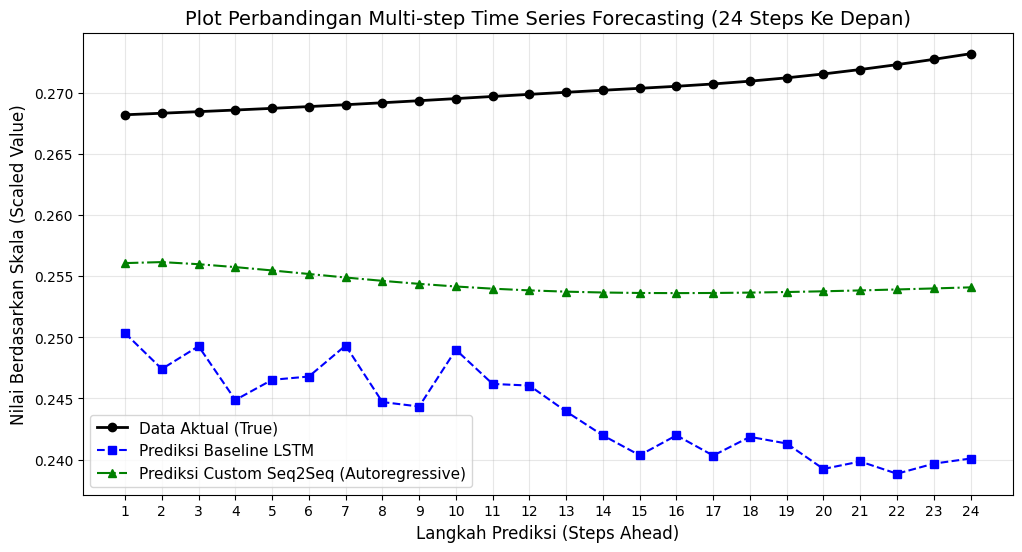


=== TABEL PERBANDINGAN MULTI-STEP FORECASTING (SAMPEL TEST KEDUA-0) ===
 Step Data Aktual Prediksi Baseline LSTM Prediksi Custom Seq2Seq Selisih Absolut Seq2Seq
    1     0.26822                0.25035                 0.25608                 0.01214
    2     0.26835                0.24742                 0.25617                 0.01218
    3     0.26848                0.24928                 0.25599                 0.01249
    4     0.26861                0.24488                 0.25575                 0.01286
    5     0.26875                0.24653                 0.25548                 0.01327
    6     0.26889                0.24680                 0.25519                 0.01370
    7     0.26905                0.24934                 0.25490                 0.01414
    8     0.26921                0.24471                 0.25463                 0.01458
    9     0.26937                0.24434                 0.25438                 0.01499
   10     0.26955                0.24

In [25]:
# Mengambil sampel indeks ke-0 pada data test untuk visualisasi horizon 24-step
sample_idx = 0
aktual_24 = y_test_ms[sample_idx]
pred_baseline_24 = baseline_preds[sample_idx]
pred_s2s_24 = seq2seq_preds[sample_idx]

# --- 1. VISUALISASI DENGAN LINE CHART ---
plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), aktual_24, marker='o', label='Data Aktual (True)', color='black', linewidth=2)
plt.plot(range(1, 25), pred_baseline_24, marker='s', label='Prediksi Baseline LSTM', color='blue', linestyle='--')
plt.plot(range(1, 25), pred_s2s_24, marker='^', label='Prediksi Custom Seq2Seq (Autoregressive)', color='green', linestyle='-.')

plt.title('Plot Perbandingan Multi-step Time Series Forecasting (24 Steps Ke Depan)', fontsize=14)
plt.xlabel('Langkah Prediksi (Steps Ahead)', fontsize=12)
plt.ylabel('Nilai Berdasarkan Skala (Scaled Value)', fontsize=12)
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()

# --- 2. TAMPILAN TABEL PERBANDINGAN DATA ---
df_compare = pd.DataFrame({
    'Step': range(1, 25),
    'Data Aktual': aktual_24,
    'Prediksi Baseline LSTM': pred_baseline_24,
    'Prediksi Custom Seq2Seq': pred_s2s_24,
    'Selisih Absolut Seq2Seq': np.abs(aktual_24 - pred_s2s_24)
})

print("\n=== TABEL PERBANDINGAN MULTI-STEP FORECASTING (SAMPEL TEST KEDUA-0) ===")
print(df_compare.to_string(index=False, formatters={
    'Data Aktual': '{:,.5f}'.format,
    'Prediksi Baseline LSTM': '{:,.5f}'.format,
    'Prediksi Custom Seq2Seq': '{:,.5f}'.format,
    'Selisih Absolut Seq2Seq': '{:,.5f}'.format
}))